Upload Dataset to Colab

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


Import file

In [2]:
import zipfile
import os

zip_path = "archive (2).zip"   # your file name
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [3]:
train_path = "/content/dataset/train"
test_path = "/content/dataset/test"

Check Dataset Structure

In [4]:
import os

base_path = "/content/dataset"
print(os.listdir(base_path))

['ST000001']


Import Libraries

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

Data Preprocessing

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 71 images belonging to 1 classes.
Found 17 images belonging to 1 classes.


Load Pretrained Model

In [7]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze for speed

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Your Model

In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

Compile Model

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision()]
)

Train Model

In [10]:
EPOCHS = 5   # keep small for speed

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision: 1.0000
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision: 1.0000
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision: 1.0000
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision: 1.0000
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - val_precision: 1.0000


Save Model

In [11]:
model.save("model.h5")

Test Model

In [12]:
loss, acc, prec = model.evaluate(val_data)

print("Accuracy:", acc)
print("Precision:", prec)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - precision: 1.0000 
Accuracy: 1.0
Precision: 1.0


Predict Single Image

In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load image safely
img = image.load_img(img_path, target_size=(224,224), color_mode='rgb')

# Convert
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Image loaded successfully ✅")

Saving IM000001.jpg to IM000001.jpg
Image loaded successfully ✅


Using Matplotlib

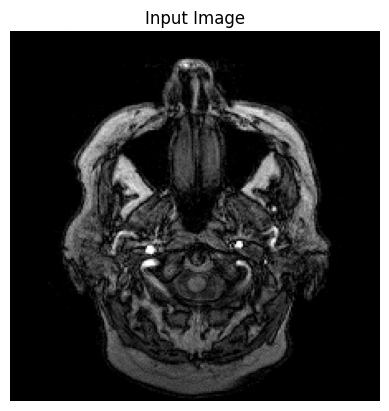

In [16]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = "/content/IM000001.jpg"

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis('off')   # axis hide
plt.title("Input Image")
plt.show()

In [17]:
!pip install gradio

GARDIO

In [18]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load model
model = load_model("model.h5")

# Class names (CHANGE according to your dataset)
class_names = ['class1', 'class2']

# Prediction function
def predict(img):
    img = img.resize((224,224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    return class_names[np.argmax(prediction)]

# Create interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Image Classification App"
)

# Launch
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bce405815df91d4d4c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="label",
    title="AI Image Classifier",
    description="Upload an image to predict its class"
)